# T3 — Recolección, Limpieza y Exploración Inicial de Datos

**Tesis:** "Diseño e Implementación de un Sistema de Recomendación Laboral para Optimizar el Matching entre Candidatos y Ofertas de Empleo"  
**Alumno:** Cicconi, Carlos Alberto  
**Maestría:** Explotación de Datos y Gestión del Conocimiento — Universidad Austral  
**Período:** 16/12/2025 – 31/12/2025

---

## Objetivo de esta etapa (T3)

Partiendo del corpus crudo generado por los scrapers (T2), esta etapa cubre:

1. **Carga y validación** del CSV consolidado (`ofertas_consolidadas.csv`)
2. **Limpieza y normalización** de campos clave (texto, fechas, ubicación, modalidad)
3. **Deduplicación** intra e inter-fuente
4. **Análisis exploratorio (EDA)** — distribuciones, coberturas, calidad del corpus
5. **Diagnóstico de la columna `descripcion`** — dato central para el motor de matching
6. **Generación del dataset limpio** listo para T4 (preprocesamiento NLP)

El archivo de entrada es `ofertas_consolidadas.csv` (2 576 filas, 17 columnas).  
El archivo de salida es `ofertas_limpias.csv` — el corpus definitivo de T4 en adelante.


## 0. Configuración del entorno

In [1]:
# ── Librerías estándar ────────────────────────────────────────────────────────
import re
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")

# ── Datos ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Estilo unificado para todos los gráficos
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (10, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("✅ Entorno configurado.")
print(f"   pandas  {pd.__version__}  |  numpy  {np.__version__}")

# ── Rutas del proyecto (resueltas desde la ubicación del notebook) ────────────
from pathlib import Path
_ROOT     = Path(globals().get('__vsc_ipynb_file__', Path.cwd())).resolve()
# Si ejecutás desde notebooks/ sube un nivel; si ya está en raíz, se queda
if _ROOT.name == 'notebooks':
    _ROOT = _ROOT.parent
_RAW      = _ROOT / 'data'    / 'raw' / 'consolidado'
_PROC     = _ROOT / 'data'    / 'processed'
_FIGS     = _ROOT / 'outputs' / 'figures'
_PROC.mkdir(parents=True, exist_ok=True)
_FIGS.mkdir(parents=True, exist_ok=True)
print(f'ROOT    : {_ROOT}')
print(f'RAW     : {_RAW}')
print(f'PROC    : {_PROC}')
print(f'FIGS    : {_FIGS}')


✅ Entorno configurado.
   pandas  2.2.3  |  numpy  2.2.4
ROOT    : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD
RAW     : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/data/raw/consolidado
PROC    : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/data/processed
FIGS    : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/outputs/figures


## 1. Carga del dataset consolidado

In [2]:
# Ruta al CSV generado por run_scraping.py / T2
CSV_PATH = _RAW / "ofertas_consolidadas.csv"
    
df_raw = pd.read_csv(CSV_PATH, low_memory=False)

print(f"Filas    : {len(df_raw)}")
print(f"Columnas : {df_raw.shape[1]}")
print(f"Memoria  : {df_raw.memory_usage(deep=True).sum() / 1024:.0f} KB")
df_raw.head(3)


Filas    : 2040
Columnas : 17
Memoria  : 17995 KB


,id_consolidado,job_id,fuente,titulo,empresa,ubicacion,descripcion,fecha_pub,fecha_pub_dt,url,keyword,nivel,tipo_empleo,modalidad,salario,fecha_scrap,fecha_consolidado
0,linkedin::4457958654,4457958654,linkedin,SR Data Scientist,Aper,Buenos Aires y alrededores,Aper es una plataforma de ecommerce para los b...,2026-08-26,2026-08-26,https://www.linkedin.com/jobs/view/4457958654,Data Scientist,Algo de responsabilidad,Jornada completa,NaN,NaN,2026-09-09T23:30:28.119612,2026-09-10T05:17:32.909298
1,linkedin::4450840542,4450840542,linkedin,Senior Data Scientist,SecurityScorecard,Buenos Aires y alrededores,About SecurityScorecard: SecurityScorecard is ...,2026-09-04,2026-09-04,https://www.linkedin.com/jobs/view/4450840542,Data Scientist,Intermedio,Jornada completa,NaN,NaN,2026-09-09T23:30:28.120124,2026-09-10T05:17:32.909298
2,linkedin::4444408017,4444408017,linkedin,Senior Data Scientist,Cashea,Buenos Aires y alrededores,¡Hola! Somos Cashea 👋 y nuestra misión es devo...,2026-07-23,2026-07-23,https://www.linkedin.com/jobs/view/4444408017,Data Scientist,No corresponde,Jornada completa,NaN,NaN,2026-09-09T23:30:28.120551,2026-09-10T05:17:32.909298


In [3]:
# Inspección general de tipos y nulos
info_df = pd.DataFrame({
    "dtype":   df_raw.dtypes.astype(str),
    "nulos":   df_raw.isnull().sum(),
    "pct_nulo": (df_raw.isnull().mean() * 100).round(1),
    "únicos":  df_raw.nunique(),
})
info_df


,dtype,nulos,pct_nulo,únicos
id_consolidado,object,0,0.0,2040
job_id,object,0,0.0,1916
fuente,object,0,0.0,9
titulo,object,0,0.0,1321
empresa,object,631,30.9,439
ubicacion,object,0,0.0,115
descripcion,object,362,17.7,1623
fecha_pub,object,327,16.0,119
fecha_pub_dt,object,0,0.0,80
url,object,0,0.0,2040


## 2. Limpieza y normalización

### 2.1 Función auxiliar de limpieza de texto

In [4]:
def limpiar_texto(t) -> str:
    """
    Normaliza un string:
      - Elimina caracteres de control (\x00-\x1f)
      - Colapsa espacios múltiples
      - Elimina espacios al inicio/fin
    Devuelve '' si el input es nulo o equivalente a 'N/A'.
    """
    if pd.isna(t):
        return ""
    t = str(t).strip()
    if t.upper() in ("N/A", "NONE", "NULL", "-"):
        return ""
    t = re.sub(r"[\x00-\x1f\x7f-\x9f]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

# Test rápido
assert limpiar_texto("  hola\n mundo  ") == "hola mundo"
assert limpiar_texto("N/A") == ""
assert limpiar_texto(None) == ""
print("✅ limpiar_texto OK")


✅ limpiar_texto OK


### 2.2 Aplicar limpieza a columnas de texto

In [5]:
TEXT_COLS = ["titulo", "empresa", "ubicacion", "descripcion",
             "keyword", "nivel", "tipo_empleo", "modalidad", "salario"]

df = df_raw.copy()

for col in TEXT_COLS:
    if col in df.columns:
        df[col] = df[col].apply(limpiar_texto)
        # Convertir cadena vacía a NaN para que isnull() funcione correctamente
        df[col] = df[col].replace("", pd.NA)

print("✅ Limpieza de texto aplicada.")
print(f"   Nulos tras limpieza — descripcion: {df['descripcion'].isna().sum()}")


✅ Limpieza de texto aplicada.
   Nulos tras limpieza — descripcion: 362


### 2.3 Normalización de la columna `keyword`

In [6]:
# El consolidado mezcla labels con slug: 'Data Scientist' y 'data-scientist'
# Normalizamos todo a label canónico limpio.

SLUG_A_LABEL = {
    "data-scientist":         "Data Scientist",
    "data-analyst":           "Data Analyst",
    "machine-learning":       "Machine Learning Engineer",
    "nlp":                    "NLP Engineer",
    "data-engineer":          "Data Engineer",
    "software-engineer":      "Software Engineer",
    "python":                 "Python Developer",
    "desarrollador-backend":  "Desarrollador Backend",
    "desarrollador-full-stack": "Desarrollador Full Stack",
    "ingeniero-de-datos":     "Ingeniero de Datos",
    "business-intelligence":  "BI / Analytics",
    "control-de-gestion":     "Control de Gestión",
    "gerente-operaciones":    "Gerente de Operaciones",
    "compras":                "Compras / Procurement",
    "ingeniero-industrial":   "Ingeniero Industrial",
    "finanzas":               "Finanzas / CAPEX",
    "excel":                  "Excel / VBA",
    "supply-chain":           "Supply Chain",
    "continuous-improvement": "Continuous Improvement",
}

df["keyword_norm"] = df["keyword"].map(
    lambda k: SLUG_A_LABEL.get(str(k).lower().strip(), k)
)

print("Keywords únicas antes:", df["keyword"].nunique())
print("Keywords únicas después:", df["keyword_norm"].nunique())
print()
print(df["keyword_norm"].value_counts())


Keywords únicas antes: 15
Keywords únicas después: 13

keyword_norm
Software Engineer            415
NLP Engineer                 222
Data Analyst                 218
Desarrollador Full Stack     208
Data Engineer                182
Ingeniero de Datos           163
Python Developer             150
Data Scientist               139
Desarrollador Backend        119
Machine Learning Engineer    117
Backend                       48
Machine Learning              37
Full Stack                    22
Name: count, dtype: int64


### 2.4 Normalización de modalidad

In [7]:
MODALIDAD_MAP = {
    # Presencial
    r"presencial":      "Presencial",
    r"on.?site":        "Presencial",
    r"in.?person":      "Presencial",
    # Remoto
    r"remoto":          "Remoto",
    r"remote":          "Remoto",
    r"full.?remote":    "Remoto",
    r"home.?office":    "Remoto",
    r"teletrabajo":     "Remoto",
    # Híbrido
    r"h.?brido":        "Híbrido",
    r"hybrid":          "Híbrido",
    # Presencial y remoto (casos mixtos)
    r"presencial.+remoto|remoto.+presencial": "Híbrido",
}

def normalizar_modalidad(val) -> str | None:
    if pd.isna(val):
        return None
    v = str(val).lower()
    for patron, label in MODALIDAD_MAP.items():
        if re.search(patron, v, re.IGNORECASE):
            return label
    return val.strip().title()  # conservar si no matchea

df["modalidad_norm"] = df["modalidad"].apply(normalizar_modalidad)
print(df["modalidad_norm"].value_counts(dropna=False))


modalidad_norm
None          1254
Remoto         351
Híbrido        273
Presencial     162
Name: count, dtype: int64


### 2.5 Normalización de ubicación

In [8]:
# Unificamos variantes comunes de Buenos Aires / Rosario / etc.
UBICACION_MAP = {
    r"capital federal": "CABA",
    r"ciudad aut.*noma": "CABA",
    r"caba": "CABA",
    r"buenos aires.*argentina|argentina.*buenos aires": "Buenos Aires, Argentina",
    r"^buenos aires$": "Buenos Aires",
    r"rosario.*santa fe|santa fe.*rosario": "Rosario, Santa Fe",
    r"^rosario$": "Rosario, Santa Fe",
    r"mendoza capital": "Mendoza",
    r"^argentina$": "Argentina",
}

def normalizar_ubicacion(val) -> str:
    if pd.isna(val):
        return "Sin datos"
    v = str(val).strip()
    for patron, label in UBICACION_MAP.items():
        if re.search(patron, v, re.IGNORECASE):
            return label
    return v

df["ubicacion_norm"] = df["ubicacion"].apply(normalizar_ubicacion)
print(df["ubicacion_norm"].value_counts().head(12))


ubicacion_norm
Argentina                     543
Remoto                        200
Buenos Aires                  195
CABA                          188
Buenos Aires, Argentina       187
Chile                         186
Buenos Aires y alrededores    169
Rosario, Santa Fe              43
Córdoba                        20
Vicente López                  15
Mendoza                        13
Buenos Aires, Buenos Aires     12
Name: count, dtype: int64


### 2.6 Normalización de fechas

In [9]:
# fecha_pub_dt ya viene procesada por run_scraping.py.
# Convertimos a datetime; 'sin-fecha' → NaT.

df["fecha_pub_dt"] = pd.to_datetime(
    df["fecha_pub_dt"].replace("sin-fecha", pd.NaT),
    errors="coerce"
)

print(f"Fechas válidas : {df['fecha_pub_dt'].notna().sum():,}")
print(f"Sin fecha      : {df['fecha_pub_dt'].isna().sum():,}")
print()
print("Rango temporal:")
print(f"  Más antigua : {df['fecha_pub_dt'].min()}")
print(f"  Más reciente: {df['fecha_pub_dt'].max()}")


Fechas válidas : 1,216
Sin fecha      : 824

Rango temporal:
  Más antigua : 2026-06-18 00:00:00
  Más reciente: 2026-09-15 00:00:00


## 3. Deduplicación

In [10]:
print("=== ANTES DE DEDUPLICAR ===")
print(f"Filas totales       : {len(df):,}")
print(f"id_consolidado únicos: {df['id_consolidado'].nunique():,}")

# Nivel 1: duplicados exactos por id_consolidado (ya garantizado por el consolidador)
dup_id = df.duplicated(subset=["id_consolidado"]).sum()
print(f"Duplicados por id_consolidado: {dup_id}")

# Nivel 2: misma URL (puede haber cross-fuente)
dup_url = df.duplicated(subset=["url"], keep="first").sum()
print(f"Duplicados por URL  : {dup_url}")

# Nivel 3: mismo título + empresa + keyword (sin URL)
dup_titcomp = df.duplicated(subset=["titulo", "empresa", "keyword_norm"], keep="first").sum()
print(f"Duplicados título+empresa+keyword: {dup_titcomp}")


=== ANTES DE DEDUPLICAR ===
Filas totales       : 2,040
id_consolidado únicos: 2,040
Duplicados por id_consolidado: 0
Duplicados por URL  : 0
Duplicados título+empresa+keyword: 558


In [11]:
# Estrategia de deduplicación:
#   1. Mantener la fila con descripción más larga cuando hay duplicados
#   2. Prioridad de fuente: linkedin > getonboard > bumeran > computrabajo > resto

FUENTE_PRIO = {
    "linkedin": 0, "getonboard": 1, "bumeran": 2, "zonajobs": 3,
    "computrabajo": 4, "workana": 5, "opcionempleo": 6,
    "jobrapido": 7, "jobomas": 8, "jobleads": 9,
}

df["_fuente_prio"] = df["fuente"].map(FUENTE_PRIO).fillna(99).astype(int)
df["_desc_len"]    = df["descripcion"].fillna("").str.len()

# Ordenar: mayor desc_len primero, luego por prioridad de fuente
df_sorted = df.sort_values(["_desc_len", "_fuente_prio"],
                           ascending=[False, True])

# Deduplicar por URL (caso más seguro)
df_dedup = df_sorted.drop_duplicates(subset=["url"], keep="first")

# Deduplicar por titulo + empresa + keyword (cross-fuente)
df_dedup = df_dedup.drop_duplicates(
    subset=["titulo", "empresa", "keyword_norm"], keep="first"
)

# Limpiar columnas auxiliares
df_dedup = df_dedup.drop(columns=["_fuente_prio", "_desc_len"])

print(f"Filas antes  : {len(df):,}")
print(f"Filas después: {len(df_dedup):,}")
print(f"Eliminadas   : {len(df) - len(df_dedup):,}  ({(1 - len(df_dedup)/len(df))*100:.1f}%)")


Filas antes  : 2,040
Filas después: 1,482
Eliminadas   : 558  (27.4%)


## 4. Diagnóstico de la columna `descripcion`

Esta columna es el **dato central** del motor de matching. Analizamos su cobertura y calidad.

In [12]:
df_dedup["_desc_len"] = df_dedup["descripcion"].fillna("").str.len()

tiene_desc = df_dedup["_desc_len"] > 50   # umbral mínimo razonable
print(f"Con descripción útil (>50 chars): {tiene_desc.sum():,}  "
      f"({tiene_desc.mean()*100:.1f}%)")
print(f"Sin descripción útil            : {(~tiene_desc).sum():,}")
print()
print("Longitud de descripción (chars) — sólo las útiles:")
print(df_dedup.loc[tiene_desc, "_desc_len"].describe().round(0))


Con descripción útil (>50 chars): 1,335  (90.1%)
Sin descripción útil            : 147

Longitud de descripción (chars) — sólo las útiles:
count     1335.0
mean      3222.0
std       1966.0
min        517.0
25%       1822.0
50%       2738.0
75%       4080.0
max      21955.0
Name: _desc_len, dtype: float64


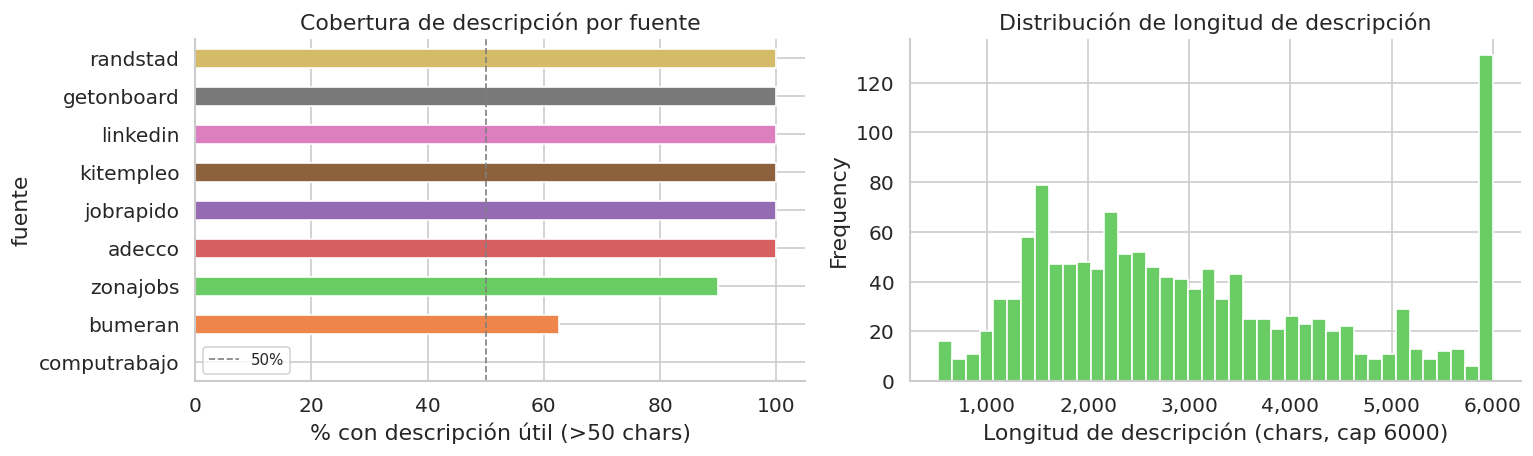

💾 fig_t3_01_cobertura_descripcion.png guardada


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Cobertura por fuente
cob = (df_dedup.groupby("fuente")["_desc_len"]
       .apply(lambda x: (x > 50).mean() * 100)
       .sort_values(ascending=True))
cob.plot(kind="barh", ax=axes[0], color=sns.color_palette("muted", len(cob)))
axes[0].set_xlabel("% con descripción útil (>50 chars)")
axes[0].set_title("Cobertura de descripción por fuente")
axes[0].axvline(50, ls="--", color="gray", lw=1, label="50%")
axes[0].legend(fontsize=9)

# Distribución de longitud
df_dedup.loc[tiene_desc, "_desc_len"].clip(upper=6000).plot(
    kind="hist", bins=40, ax=axes[1],
    color=sns.color_palette("muted")[2], edgecolor="white"
)
axes[1].set_xlabel("Longitud de descripción (chars, cap 6000)")
axes[1].set_title("Distribución de longitud de descripción")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig(_FIGS / "fig_t3_01_cobertura_descripcion.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 fig_t3_01_cobertura_descripcion.png guardada")


## 5. Análisis Exploratorio (EDA)

### 5.1 Distribución por fuente

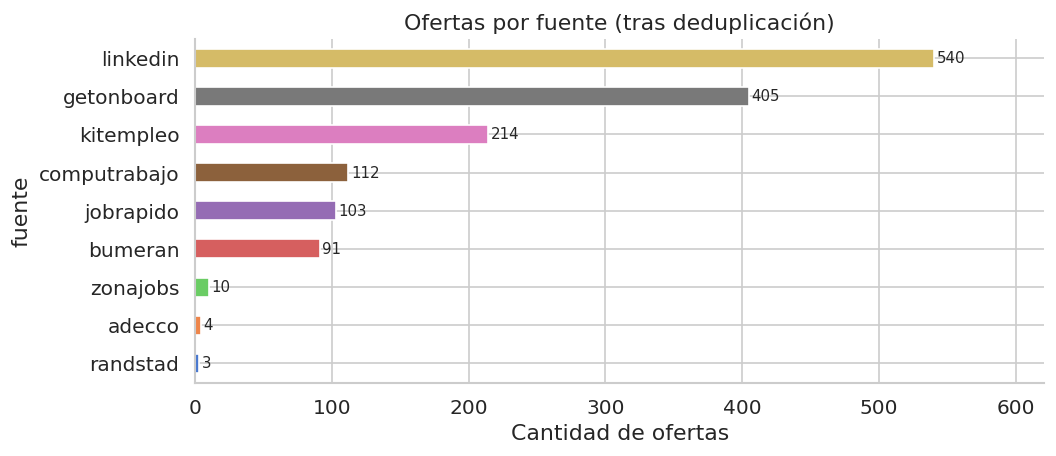

Total ofertas únicas: 1,482


In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
cnt = df_dedup["fuente"].value_counts().sort_values()
bars = cnt.plot(kind="barh", ax=ax, color=sns.color_palette("muted", len(cnt)))
for bar, val in zip(bars.patches, cnt.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9)
ax.set_xlabel("Cantidad de ofertas")
ax.set_title("Ofertas por fuente (tras deduplicación)")
ax.set_xlim(0, cnt.max() * 1.15)
plt.tight_layout()
plt.savefig(_FIGS / "fig_t3_02_ofertas_por_fuente.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Total ofertas únicas: {len(df_dedup):,}")


### 5.2 Distribución por keyword

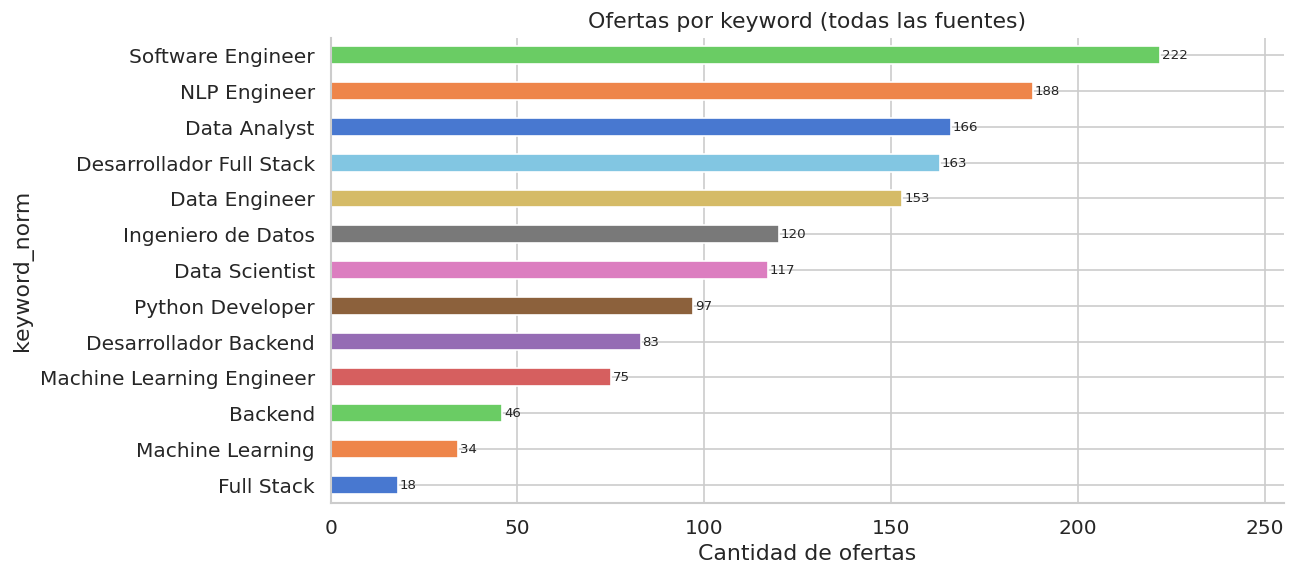

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
cnt_kw = df_dedup["keyword_norm"].value_counts().sort_values()
colors = sns.color_palette("muted", len(cnt_kw))
bars = cnt_kw.plot(kind="barh", ax=ax, color=colors)
for bar, val in zip(bars.patches, cnt_kw.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=8)
ax.set_xlabel("Cantidad de ofertas")
ax.set_title("Ofertas por keyword (todas las fuentes)")
ax.set_xlim(0, cnt_kw.max() * 1.15)
plt.tight_layout()
plt.savefig(_FIGS / "fig_t3_03_ofertas_por_keyword.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.3 Heatmap: fuente × keyword

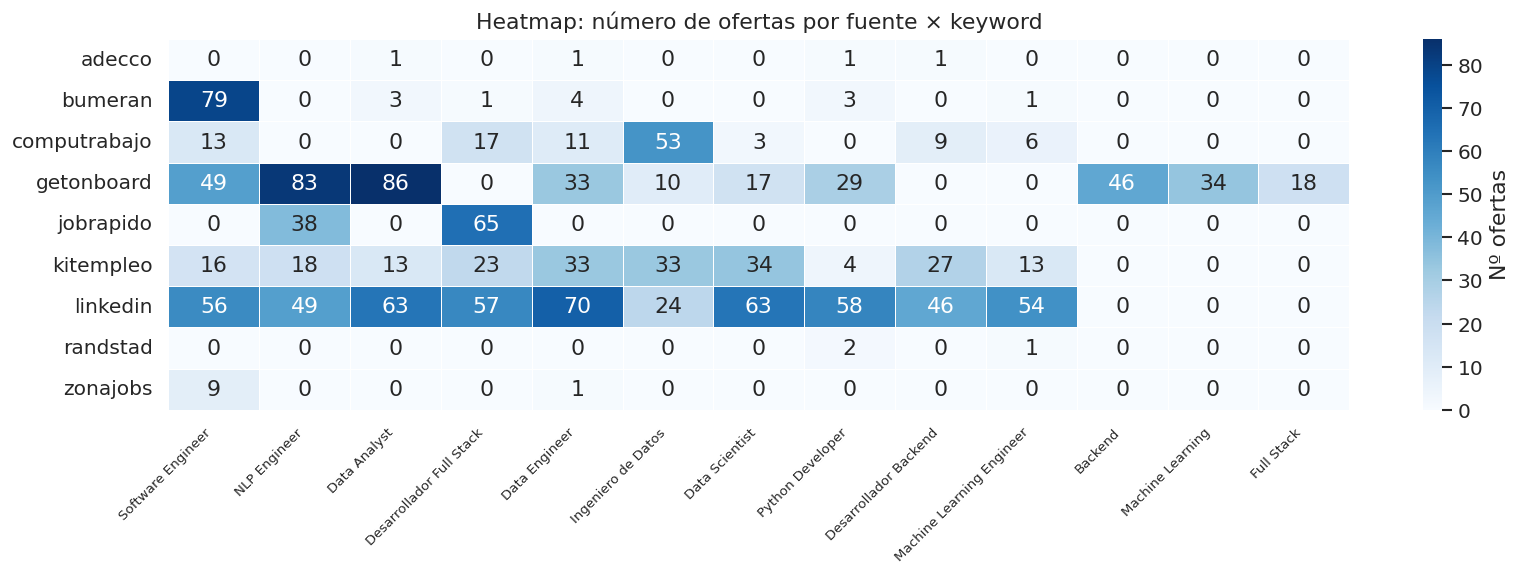

In [16]:
pivot = (df_dedup.groupby(["fuente", "keyword_norm"])
         .size().unstack(fill_value=0))

# Ordenar keywords por total
pivot = pivot[pivot.sum().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues",
            linewidths=0.4, ax=ax, cbar_kws={"label": "Nº ofertas"})
ax.set_title("Heatmap: número de ofertas por fuente × keyword")
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(_FIGS / "fig_t3_04_heatmap_fuente_keyword.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.4 Distribución temporal

Ofertas con fecha válida: 1,043 / 1,482


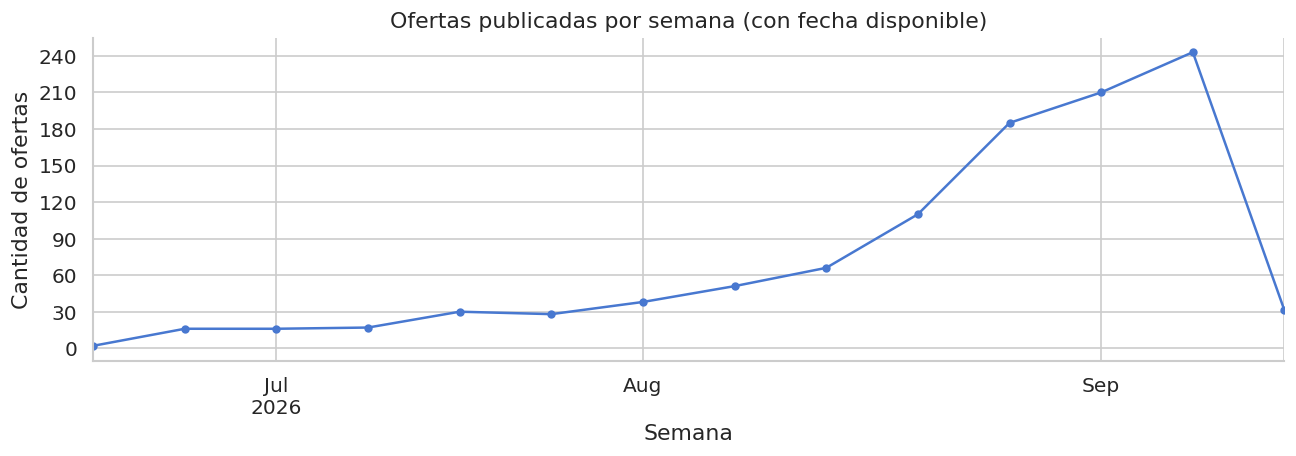

In [17]:
df_con_fecha = df_dedup.dropna(subset=["fecha_pub_dt"])
print(f"Ofertas con fecha válida: {len(df_con_fecha):,} / {len(df_dedup):,}")

if len(df_con_fecha) > 0:
    fig, ax = plt.subplots(figsize=(11, 4))
    df_con_fecha.set_index("fecha_pub_dt").resample("W")["id_consolidado"].count().plot(
        ax=ax, marker="o", ms=4, color=sns.color_palette("muted")[0]
    )
    ax.set_title("Ofertas publicadas por semana (con fecha disponible)")
    ax.set_xlabel("Semana")
    ax.set_ylabel("Cantidad de ofertas")
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.savefig(_FIGS / "fig_t3_05_temporal.png", dpi=150, bbox_inches="tight")
    plt.show()


### 5.5 Distribución de modalidad

modalidad_norm
None          919
Remoto        284
Híbrido       207
Presencial     72
Name: count, dtype: int64


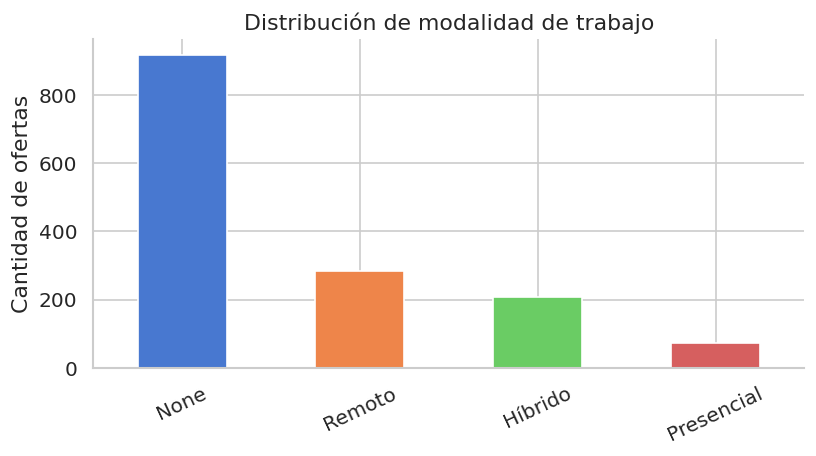

In [18]:
mod_counts = df_dedup["modalidad_norm"].value_counts(dropna=False)
print(mod_counts)

fig, ax = plt.subplots(figsize=(7, 4))
colores = sns.color_palette("muted", len(mod_counts.dropna()))
mod_counts.dropna().plot(kind="bar", ax=ax, color=colores, edgecolor="white")
ax.set_title("Distribución de modalidad de trabajo")
ax.set_xlabel("")
ax.set_ylabel("Cantidad de ofertas")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.savefig(_FIGS / "fig_t3_06_modalidad.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.6 Top ubicaciones

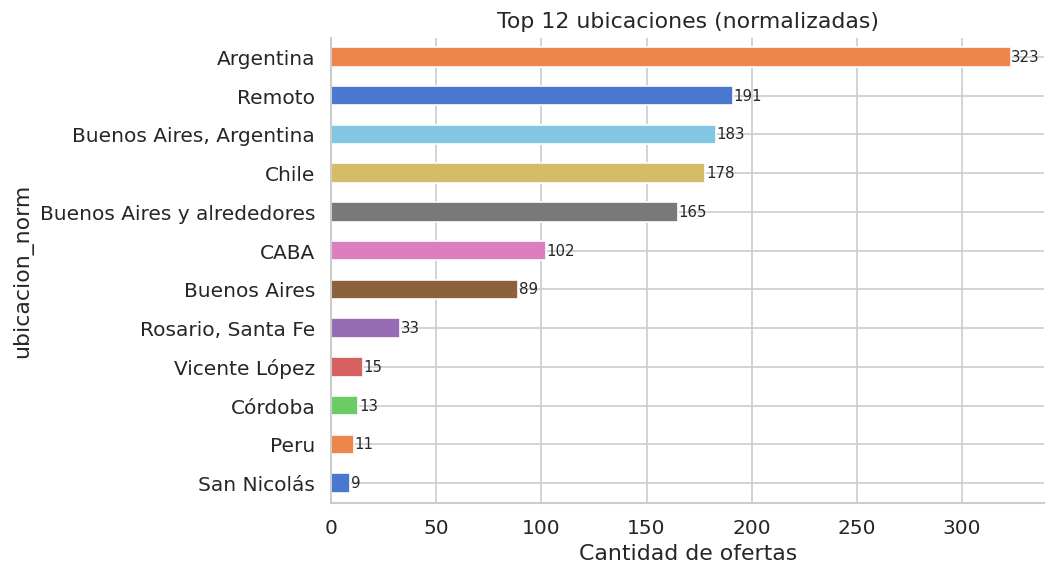

In [19]:
top_ub = df_dedup["ubicacion_norm"].value_counts().head(12)
fig, ax = plt.subplots(figsize=(9, 5))
top_ub.sort_values().plot(kind="barh", ax=ax,
                           color=sns.color_palette("muted", len(top_ub)))
ax.set_xlabel("Cantidad de ofertas")
ax.set_title("Top 12 ubicaciones (normalizadas)")
for bar, val in zip(ax.patches, top_ub.sort_values().values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=9)
plt.tight_layout()
plt.savefig(_FIGS / "fig_t3_07_ubicaciones.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Resumen de calidad del corpus

In [20]:
# ── Scorecard de calidad ─────────────────────────────────────────────────────
N = len(df_dedup)
tiene_titulo   = df_dedup["titulo"].notna().sum()
tiene_empresa  = df_dedup["empresa"].notna().sum()
tiene_desc_ok  = (df_dedup["_desc_len"] > 50).sum()
tiene_fecha    = df_dedup["fecha_pub_dt"].notna().sum()
tiene_modalidad= df_dedup["modalidad_norm"].notna().sum()
tiene_ubicacion= (df_dedup["ubicacion_norm"] != "Sin datos").sum()

scorecard = pd.DataFrame({
    "Campo": ["titulo", "empresa", "descripcion (>50 chars)",
               "fecha_pub", "modalidad", "ubicacion"],
    "Con dato": [tiene_titulo, tiene_empresa, tiene_desc_ok,
                  tiene_fecha, tiene_modalidad, tiene_ubicacion],
    "% cobertura": [f"{v/N*100:.1f}%" for v in [
        tiene_titulo, tiene_empresa, tiene_desc_ok,
        tiene_fecha, tiene_modalidad, tiene_ubicacion]]
})
scorecard.index = scorecard.index + 1
print(f"Total ofertas únicas en el corpus limpio: {N:,}\n")
print(scorecard.to_string(index=False))


Total ofertas únicas en el corpus limpio: 1,482

                  Campo  Con dato % cobertura
                 titulo      1482      100.0%
                empresa       960       64.8%
descripcion (>50 chars)      1335       90.1%
              fecha_pub      1043       70.4%
              modalidad       563       38.0%
              ubicacion      1482      100.0%


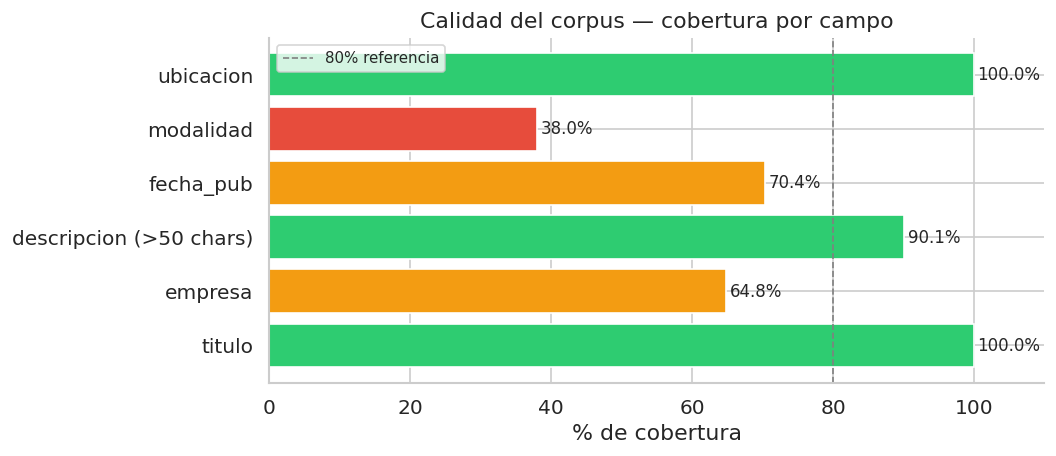

In [21]:
# Visualización del scorecard
fig, ax = plt.subplots(figsize=(9, 4))
campos = scorecard["Campo"].tolist()
coberturas = [float(p.replace("%","")) for p in scorecard["% cobertura"].tolist()]

colores = ["#2ecc71" if c >= 80 else "#f39c12" if c >= 50 else "#e74c3c"
           for c in coberturas]
bars = ax.barh(campos, coberturas, color=colores, edgecolor="white")
for bar, val in zip(bars, coberturas):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=10)
ax.axvline(80, ls="--", color="gray", lw=1, label="80% referencia")
ax.set_xlim(0, 110)
ax.set_xlabel("% de cobertura")
ax.set_title("Calidad del corpus — cobertura por campo")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(_FIGS / "fig_t3_08_calidad_corpus.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Dataset limpio para T4

Generamos el dataset que entrará al pipeline de preprocesamiento NLP.  
**Criterio de inclusión:** el campo `descripcion` debe tener al menos 50 caracteres  
(garantiza que haya texto real para vectorizar en T4 y T5).

In [22]:
# Dataset completo limpio (todas las ofertas, con y sin descripción)
COLS_SALIDA = [
    "id_consolidado", "job_id", "fuente",
    "titulo", "empresa", "ubicacion_norm",
    "descripcion", "fecha_pub_dt",
    "url", "keyword_norm",
    "nivel", "tipo_empleo", "modalidad_norm", "salario",
    "fecha_scrap",
]

df_limpio = (
    df_dedup[COLS_SALIDA]
    .rename(columns={
        "ubicacion_norm": "ubicacion",
        "keyword_norm":   "keyword",
        "modalidad_norm": "modalidad",
    })
    .reset_index(drop=True)
)

# Dataset restringido para el motor de matching (solo los que tienen descripción > 50 chars)
df_matching = df_limpio[df_limpio["descripcion"].fillna("").str.len() > 50].copy()

print(f"Dataset limpio completo   : {len(df_limpio):,} filas")
print(f"Dataset para matching     : {len(df_matching):,} filas")
print(f"Cobertura descripción     : {len(df_matching)/len(df_limpio)*100:.1f}%")


Dataset limpio completo   : 1,482 filas
Dataset para matching     : 1,335 filas
Cobertura descripción     : 90.1%


In [23]:
# Guardar ambos archivos
df_limpio.to_csv(_PROC / "ofertas_limpias.csv", index=False, encoding="utf-8")
df_matching.to_csv(_PROC / "ofertas_con_descripcion.csv", index=False, encoding="utf-8")

print("✅ Archivos guardados:")
print(f"   📄 ofertas_limpias.csv              — {len(df_limpio):,} filas (corpus completo)")
print(f"   📄 ofertas_con_descripcion.csv      — {len(df_matching):,} filas (para matching)")


✅ Archivos guardados:
   📄 ofertas_limpias.csv              — 1,482 filas (corpus completo)
   📄 ofertas_con_descripcion.csv      — 1,335 filas (para matching)


In [24]:
# Vista previa del dataset para matching
df_matching[["fuente","titulo","empresa","ubicacion","keyword","modalidad"]].head(10)


,fuente,titulo,empresa,ubicacion,keyword,modalidad
0,linkedin,Senior Data Scientist,StartX Med,Argentina,Data Scientist,None
1,linkedin,"Principal AI-Native Engineer, Ionic Partners",Sparkrock,Buenos Aires y alrededores,NLP Engineer,None
2,linkedin,"Senior Data Analyst, B2B",CookUnity,Argentina,Data Analyst,None
3,kitempleo,Security Management - Data Engineer - EY Globa...,Ernst & Young Advisory Services Sdn Bhd,Buenos Aires,Data Engineer,None
4,linkedin,Principal Computer Vision Scientist,Sourceability,"Buenos Aires, Argentina",Machine Learning Engineer,None
5,kitempleo,"Sr. Software Engineer, AI / ML Inference Platf...",Empresa líder,Buenos Aires,NLP Engineer,None
6,kitempleo,"Sr. Software Engineer, AI / ML Inference Platf...",Dialpad,Buenos Aires,NLP Engineer,None
7,kitempleo,"Sr. Software Engineer, Ai / Ml Inference Platf...",Dialpad,Buenos Aires,NLP Engineer,None
8,kitempleo,Embedded Python Data & Automation Engineer (Ar...,Pavago,Argentina,Python Developer,None
9,kitempleo,"Sr. Software Engineer, AI / ML Inference Platf...",Linuxconfig,Argentina,NLP Engineer,None


## 8. Resumen ejecutivo de T3

In [25]:
from datetime import datetime

print("=" * 60)
print("  RESUMEN — T3: Recolección, Limpieza y EDA")
print("=" * 60)
print()
print(f"  Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print()
print("  ENTRADA")
print(f"    CSV consolidado (T2): {len(df_raw):,} filas × {df_raw.shape[1]} columnas")
print()
print("  PROCESAMIENTO")
print(f"    Limpieza de texto  : 9 columnas normalizadas")
print(f"    Deduplicación      : -{len(df) - len(df_dedup):,} filas eliminadas")
print(f"    Keyword norm.      : slugs → labels canónicos")
print(f"    Modalidad norm.    : variantes → 4 categorías")
print(f"    Ubicación norm.    : variantes → formas canónicas")
print()
print("  SALIDA — corpus limpio")
print(f"    Total ofertas únicas : {len(df_limpio):,}")
print(f"    Con descripción útil : {len(df_matching):,}  ({len(df_matching)/len(df_limpio)*100:.1f}%)")
print(f"    Fuentes cubiertas    : {df_limpio['fuente'].nunique()}")
print(f"    Keywords cubiertas   : {df_limpio['keyword'].nunique()}")
print()
print("  ARCHIVOS GENERADOS")
print("    📄 ofertas_limpias.csv         → entrada opcional T4")
print("    📄 ofertas_con_descripcion.csv → entrada principal T4 (matching)")
print("    🖼  fig_01 a fig_08.png        → gráficos del EDA")
print()
print("  PRÓXIMO PASO: T4 — Preprocesamiento de Texto y TF-IDF")
print("=" * 60)


  RESUMEN — T3: Recolección, Limpieza y EDA

  Fecha de ejecución: 2026-09-15 22:55

  ENTRADA
    CSV consolidado (T2): 2,040 filas × 17 columnas

  PROCESAMIENTO
    Limpieza de texto  : 9 columnas normalizadas
    Deduplicación      : -558 filas eliminadas
    Keyword norm.      : slugs → labels canónicos
    Modalidad norm.    : variantes → 4 categorías
    Ubicación norm.    : variantes → formas canónicas

  SALIDA — corpus limpio
    Total ofertas únicas : 1,482
    Con descripción útil : 1,335  (90.1%)
    Fuentes cubiertas    : 9
    Keywords cubiertas   : 13

  ARCHIVOS GENERADOS
    📄 ofertas_limpias.csv         → entrada opcional T4
    📄 ofertas_con_descripcion.csv → entrada principal T4 (matching)
    🖼  fig_01 a fig_08.png        → gráficos del EDA

  PRÓXIMO PASO: T4 — Preprocesamiento de Texto y TF-IDF
